## Data Quality Assessment
Observations:

- Dataset contains 3074 daily observations.
- No missing values were detected.
- Columns are stored as a MultiIndex structure generated by yfinance.
- Since only BTC-USD is analyzed, the ticker level does not provide additional information and will be flattened before analysis.

## Understanding why it generated MultiIndex:
yfinance uses a MultiIndex structure because it is designed to support downloading multiple assets simultaneously. The first level identifies the financial variable (Open, High, Low, Close, Volume), while the second level identifies the asset ticker. When only one asset is downloaded, the ticker level becomes redundant because every column belongs to the same asset. However, preserving awareness of this structure is important because future versions of the project may incorporate multiple assets.

In [33]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
%matplotlib inline

# Ruta absoluta a la raíz del proyecto
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
# Configurations
from config import ASSETS, INTERVAL, RAW_DATA_PATH, PROCESSED_DATA_PATH

------

## Load Dataset

In this section, we load the historical Bitcoin price dataset collected during the data acquisition phase.

The objective is to verify that the dataset has been loaded correctly before proceeding with exploratory data analysis. Specifically, we inspect the first observations to confirm:

- The dataset structure.
- The available variables.
- The date index.
- The presence of price and volume information.

Any structural issues identified at this stage must be corrected before continuing with the analysis.

In [21]:
# Load dataset
asset_name = ASSETS[0].lower().replace("-", "_")

file_path = f"{RAW_DATA_PATH}/{asset_name}_{INTERVAL}_raw.csv"

df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [23]:
# Display dataset information
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-01,13657.200195,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [24]:
# Display basic information about the dataset to verify if it loads correctly
df.info()
df.columns

<class 'pandas.DataFrame'>
DatetimeIndex: 3081 entries, 2018-01-01 to 2026-06-08
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3081 non-null   float64
 1   Close      3081 non-null   float64
 2   High       3081 non-null   float64
 3   Low        3081 non-null   float64
 4   Open       3081 non-null   float64
 5   Volume     3081 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 168.5 KB


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

-------

## Dataset Overview

Before performing any statistical or visual analysis, it is important to understand the basic characteristics of the dataset.

The objective of this section is to evaluate:

- Dataset dimensions.
- Data types.
- Missing values.
- General structure.

This helps ensure the data is suitable for subsequent exploratory analysis and feature engineering.

In [28]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3081
Columns: 6


### Dataset Dimensions Interpretation

The dataset contains 3,081 observations and 6 financial variables. This represents a substantial historical record of Bitcoin market activity spanning multiple market cycles.

The number of observations is sufficient for exploratory analysis, feature engineering, dimensionality reduction, and clustering techniques that will be applied in later stages of the project.

Additionally, the dataset includes both price-related variables and trading volume information, providing a solid foundation for identifying different market regimes.

In [29]:
# Data type analysis
df.dtypes

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

In [32]:
# Display the idnex to understand what it is and why we have it as a DateTimeIndex
print(type(df.index))
print(df.index[:5])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05'],
              dtype='datetime64[us]', name='Date', freq=None)


### Data Type Interpretation

All financial variables were loaded using appropriate numerical data types.

Price-related variables (Open, High, Low, Close, and Adjusted Close) are stored as float64 values, allowing for precise numerical calculations. Trading volume is stored as int64, which is appropriate because volume represents discrete transaction counts.

The Date variable is not displayed among the columns because it has been converted into a DatetimeIndex. This is the preferred structure for time-series analysis and will facilitate subsequent calculations, visualizations, and feature engineering tasks.

In [31]:
# Missing values 
df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

### Missing Values Interpretation

The missing values analysis shows that no variables contain null observations.

This indicates that the dataset is complete and no imputation, interpolation, or row removal procedures are required before continuing with the analysis.

Having a complete dataset is particularly important for time-series modeling because missing observations can distort return calculations, rolling statistics, and clustering results. Therefore, the dataset is considered ready for the next stages of exploratory analysis and feature engineering.

------ 

## Price Behavior Analysis
In this section we should try ton understan the following questions to understan better what we are looking for:
- How has Bitcoin evolved since 2018?
- Are there clearly distinguishable bull and bear markets?
- Are there periods of extreme volatility?
- Can we visually identify potential market regimes?

Before calculating returns, volatility, momentum, PCA, or clustering, we should first understand the raw price behavior.

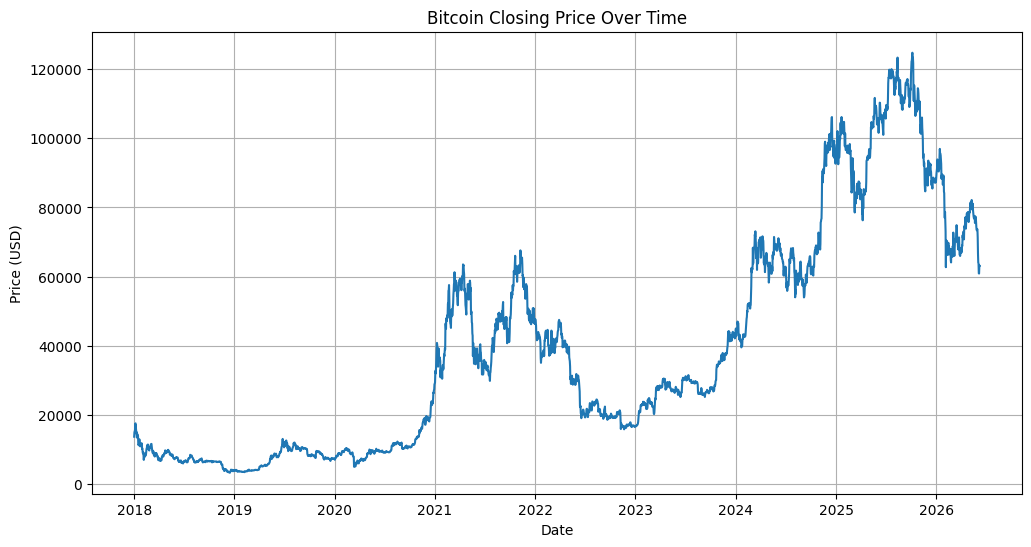

In [34]:
# Visualize the data to understand it better
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"])

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)

----- 

In [ ]:
#